=== MRI Field Simulation ===
Запуск стационарного расчета магнитного поля...


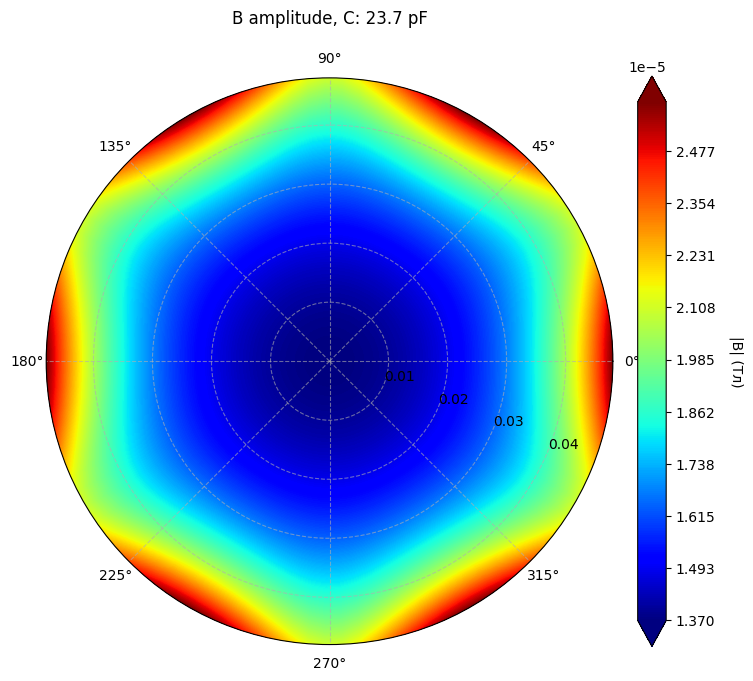

Цветовая карта сохранена в 'B_field_contour.png'
Расчет поля вдоль оси X...
График вдоль оси X сохранен в 'B_field_along_X.png'
Значение целевой функции: 1.318574e-03

[Data Logging] Результаты успешно зафиксированы в: ./results\run_20260527_200808


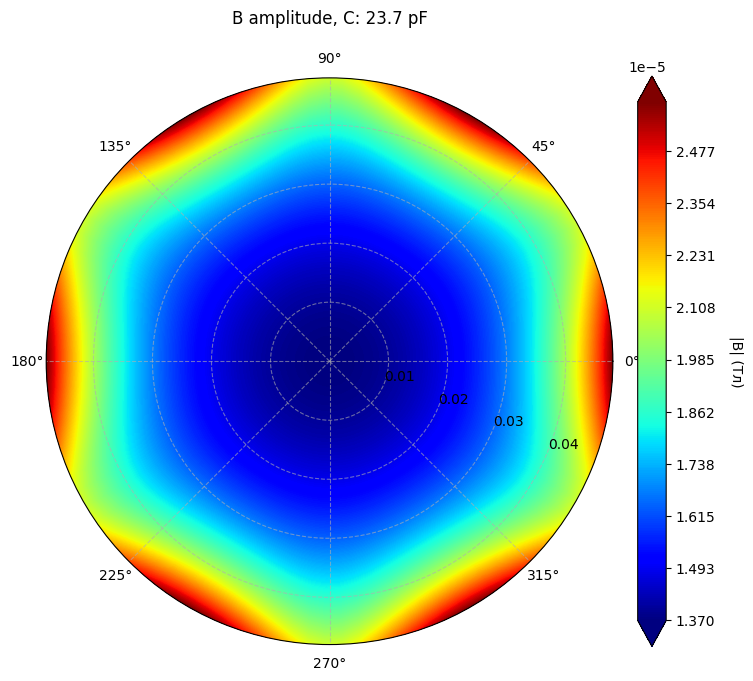

In [3]:
import numpy as np
import os
import json
from datetime import datetime
import src.config as config  
import matplotlib.pyplot as plt
from src.geometry import points_on_rings_general, ring_center_general
from src.inductance import inductance_matrix
from src.currents import Z_self_matrix, generate_voltage_array, calc_I
from src.magnetic_field import b_s_l_optimized, quality_metric
from src.visualization import plot_field_contour, plot_field_along_axis
from src.utils import create_run_directory, save_simulation_data

print("=== MRI Field Simulation ===")

print("Запуск стационарного расчета магнитного поля...")

# 1. Загрузка параметров
m, n, radii, gaps = config.m, config.n, config.radii, config.gaps
A, N_seg, omega, r_ohm, U_0, C = config.A, config.N_seg, config.omega, config.r_ohm, config.U_0, config.C

# 2. Расчет геометрии и индуктивностей
all_coords, normals = points_on_rings_general(delta=gaps, n=n, A=A, N=N_seg, R=radii, m=m)
L = inductance_matrix(n=n, m=m, R=radii, L_own=config.L_self, A=A, delta=gaps, all_points=all_coords, normals=normals, N_seg=N_seg)

# 3. Расчет матриц токов
Z_self = Z_self_matrix(r=r_ohm, C=C, n=n, m=m, R=radii, omega=omega)
U = generate_voltage_array(U_0=U_0, m=m, n=n)
I_flat = calc_I(Z_self=Z_self, L=L, omega=omega, U=U, n=n, m=m)
I_matrix = I_flat.reshape((m, n))

# Массив центров колец для расчетов
fi = (2 * np.pi) / m
ring_centers = np.array([ring_center_general(gaps, A, n, fi, s, r) for s in range(m) for r in range(n)])

# Цветовая карта
phi = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 0.6 * config.A, 100)
R, Phi = np.meshgrid(r, phi, indexing='ij')

X = R * np.cos(Phi)
Y = R * np.sin(Phi)
obs_points_2d = np.stack((X.ravel(), Y.ravel(), np.zeros_like(X.ravel())), axis=1)
B_2d_complex = b_s_l_optimized(obs_points_2d, I_matrix, n, m, ring_centers, normals, radii)
B_2d_amp = np.linalg.norm(B_2d_complex, axis=1).reshape(X.shape)

plot_field_contour(
    Phi=Phi, R=R, B_magnitude=B_2d_amp, C=C,
    title=f'B amplitude, (C = {C[0] * 1e12:.1f} pF,f = {config.frequency_MHz} МГц)',
    save_path='B_field_contour.png'
)

print("Цветовая карта сохранена в 'B_field_contour.png'")

# График амплитуды вдоль оси X
print("Расчет поля вдоль оси X...")

x_line = np.linspace(-0.05, 0.05, 200) 
obs_points_1d = np.stack((x_line, np.zeros_like(x_line), np.zeros_like(x_line)), axis=1)

B_1d_complex = b_s_l_optimized(obs_points_1d, I_matrix, n, m, ring_centers, normals, radii)
B_1d_amp = np.linalg.norm(B_1d_complex, axis=1)

plot_field_along_axis(
    axis_coords=x_line, B_amplitude=B_1d_amp, axis_name='X',
    title='Профиль амплитуды поля |B| вдоль оси X',
    save_path='B_field_along_X.png'
)
print("График вдоль оси X сохранен в 'B_field_along_X.png'")
print(f"Значение целевой функции: {quality_metric(I_matrix, n, m, ring_centers, normals, radii, R_domain=config.R_domain):.6e}")

current_config = {
    'frequency_MHz': 68.5,
    'n': n,
    'm': m,
    'A': A, 
    'C': C,
    'gaps': gaps,
    'Значение целевой функции': quality_metric(I_matrix, n, m, ring_centers, normals, radii, R_domain=config.R_domain) 
    #добавить сюда оптимизированные параметры
}

matrices_to_save = {
    'L_matrix': L,
    'I_vector': I_matrix,
    'B_2d_amplitude': B_2d_amp,
    'X_grid': X,
    'Y_grid': Y
}

# Шаг 1: Создаем уникальную папку
run_folder = create_run_directory()

# Шаг 2: Сохраняем конфиг и массивы
save_simulation_data(run_folder, current_config, matrices_to_save)

# Шаг 3: Передаем этот же путь в функции отрисовки графиков
plot_field_contour(
    Phi=Phi, R=R, B_magnitude=B_2d_amp, C=C,
    title=f'B amplitude, (C = {C[0] * 1e12:.1f} pF,f = {config.frequency_MHz} МГц)',
    save_path=os.path.join(run_folder, "B_field_contour.png") #
)
plot_field_along_axis(
    axis_coords=x_line, B_amplitude=B_1d_amp, axis_name='X',
    title='Профиль амплитуды поля |B| вдоль оси X',
    save_path=os.path.join(run_folder, "B_field_along_X.png")
)


In [1]:
import numpy as np

S = 1.14563838e-02
k1, k2, k3 = 3.29859053e-02, 4.11406771e-02, 3.78943057e-02


# Распределяем общую сумму S между четырьмя дельтами
d1 = S * k1
d2 = (S - d1) * k2
d3 = (S - d1 - d2) * k3
d4 = S - d1 - d2 - d3

deltas = np.array([d1, d2, d3, d4])
print(sum(deltas))

0.0114563838
